# Ejercicio 7

En este ejercicio se propone verificar la predicción de ley de Zipf. Para ello, descargue desde Project Gutenberg el texto del Quijote de Cervantes y escriba un programa que extraiga los términos y calcule sus frecuencias (el programa debe generar la lista ordenada por frecuencia descendente). Calcule la curva de ajuste utilizando la función Polyfit del módulo NumPy. Con los datos crudos y los estimados grafique en la notebook ambas distribuciones (haga 2 gráficos, uno en escala lineal y otro en log-log). ¿Cómo se comporta la predicción? ¿Qué conclusiones puede obtener? 

## 1. Importar

In [57]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

with open("pg2000.txt", encoding="utf-8") as f:
    texto = f.read().lower() # Paso a minusculas



In [58]:
print(f"Total de palabras: {len(texto)}")

Total de palabras: 2130058


## 2. Tokenizacion

In [59]:
tokens = re.findall(r"[a-záéíóúüñ]+", texto)

print(f"Tokens: {len(tokens)}")
print(f"Vocabulario: {len(set(tokens))}")

Tokens: 386686
Vocabulario: 23575


## 3. Frecuencia

In [60]:
frecuencias = Counter(tokens) # Tengo el conteo de frecuencias

# Ordenar por frecuencia
ranking = frecuencias.most_common()

print("Palabra mas freceuentes:")
for palabra, freq in frecuencias.most_common(10):
    print(f"{palabra}: {freq}")

Palabra mas freceuentes:
que: 20769
de: 18411
y: 18272
la: 10492
a: 9934
en: 8285
el: 8267
no: 6356
los: 4769
se: 4752


## 4. Ley de Zipf (Con Polyfit)

In [61]:
# Rangos y frecuencias
rangos = np.array([i for i in range(1, len(ranking)+1)]) # Posicion en el ranking
freqs = np.array([freq for _, freq in ranking]) # Frecuencia de esa palabra

In [62]:
# Pasar a escala log-log
log_rangos = np.log(rangos)
log_freqs = np.log(freqs)

In [63]:
#A Ajuste de la recta
pendiente, intercepto = np.polyfit(log_rangos, log_freqs, 1)

print("Pendiente:", pendiente)
print("Intercepto:", intercepto)

Pendiente: -1.2101377686404917
Intercepto: 11.864996769102202


### Grafico 1 - Lineal

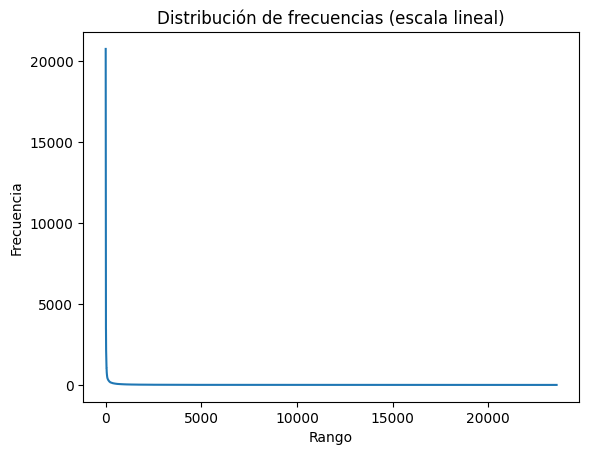

In [64]:
plt.figure()

plt.plot(rangos, freqs)

plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.title("Distribución de frecuencias (escala lineal)")

plt.show()

### Grafico 2 - Log-Log

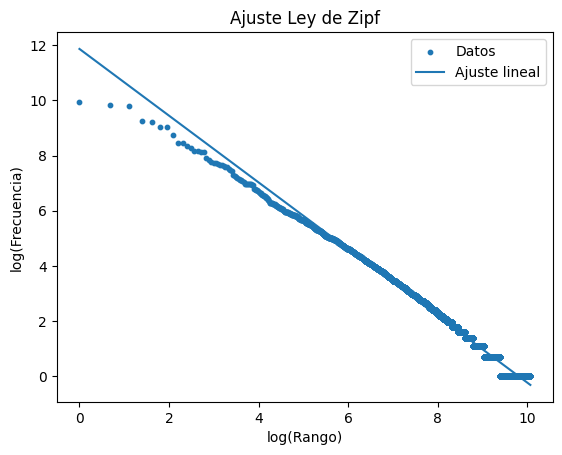

In [65]:
# Plot

plt.scatter(log_rangos, log_freqs, s=10, label="Datos")
ajuste = pendiente * log_rangos + intercepto
plt.plot(log_rangos, ajuste, label="Ajuste lineal")

plt.xlabel("log(Rango)")
plt.ylabel("log(Frecuencia)")
plt.title("Ajuste Ley de Zipf")
plt.legend()

plt.show()